# Natural Language Processing (NLP)

**Natural Language Processing (NLP) is a field that combines computer science, artificial intelligence and linguistics to enable computers to understand, process and generate human language in a meaningful way.** With the growing amount of text data from social media, websites and other sources, NLP is becoming a key tool to gain insights and automate tasks like analyzing text or translating languages.

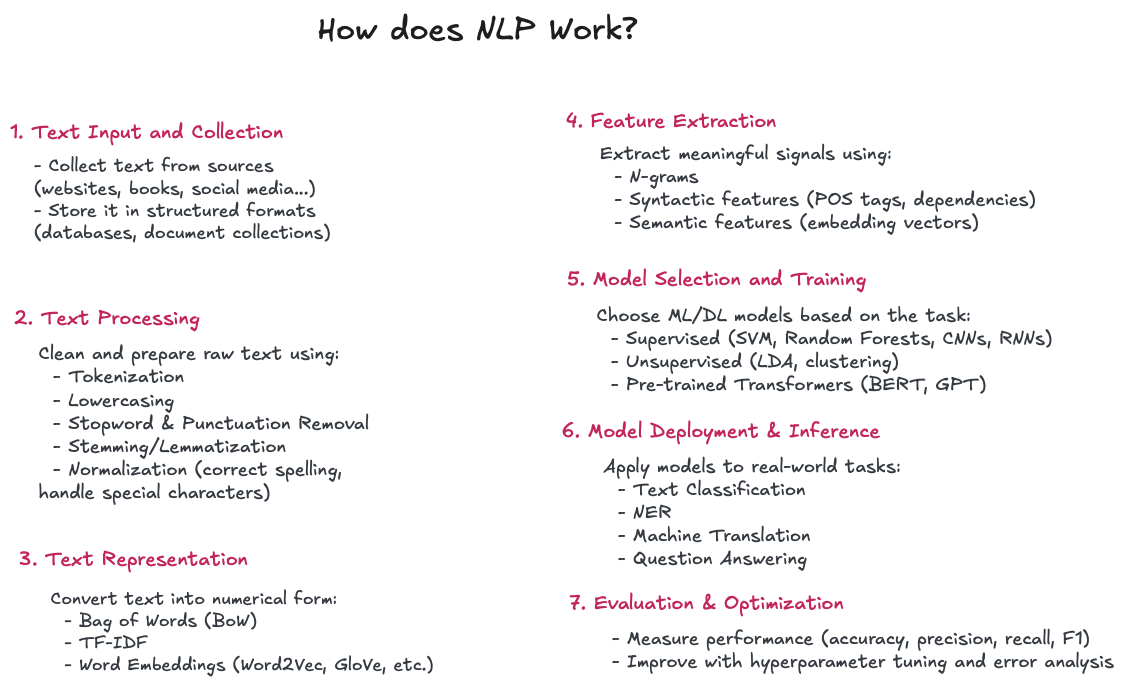

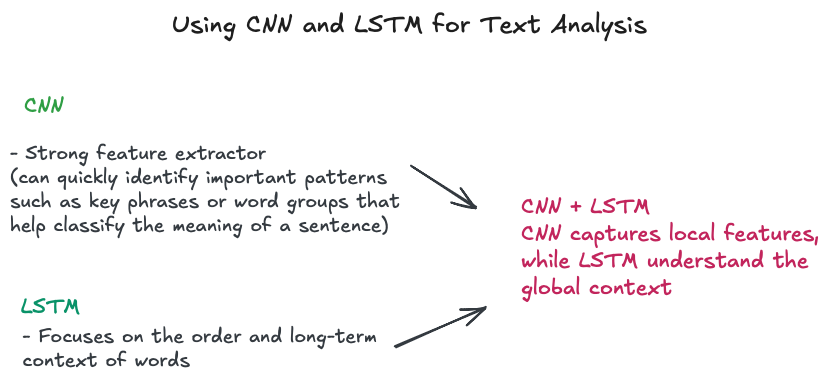

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Conv1D, MaxPooling1D, LSTM
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
df = pd.read_csv("emotions-dataset.csv")
df

,message,emotion
0,i used to be able to hang around talk with the...,anger
1,i get made to feel left out and unimportant in...,sadness
2,i wasnt going to post today as i am feeling qu...,sadness
3,i feel extremely delicate and a bit helpless,love
4,i feel frightened that i might fail to notice ...,fear
...,...,...
11995,i feel useless for wasting k hours k just for ...,sadness
11996,i feel rushed and pulled and rung out and i kn...,anger
11997,i feel absolutely disgusted,anger
11998,i know that we are all sinners and fall short ...,sadness


Check if the dataset is balanced.

<Axes: xlabel='emotion'>

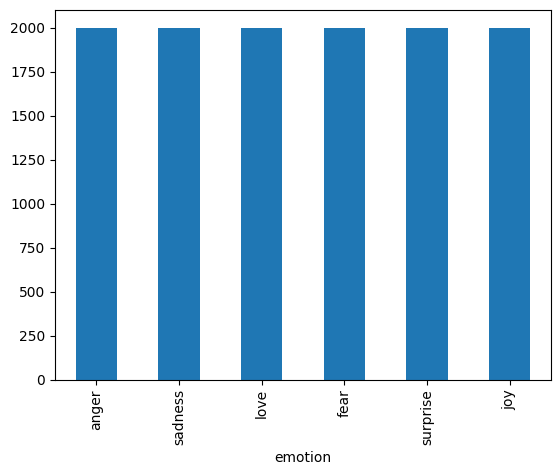

In [3]:
df["emotion"].value_counts().plot.bar()

Check if there are missing values.

In [4]:
df.isnull().sum()

message    0
emotion    0
dtype: int64

Plot the distribution of words per text.

<Axes: ylabel='Frequency'>

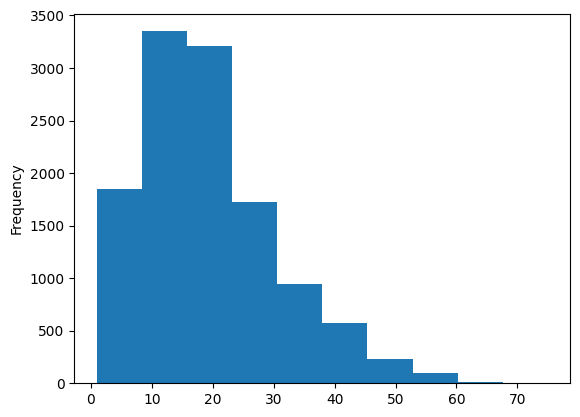

In [5]:
df["message"].str.split(" ").apply(len).plot.hist()

<Axes: >

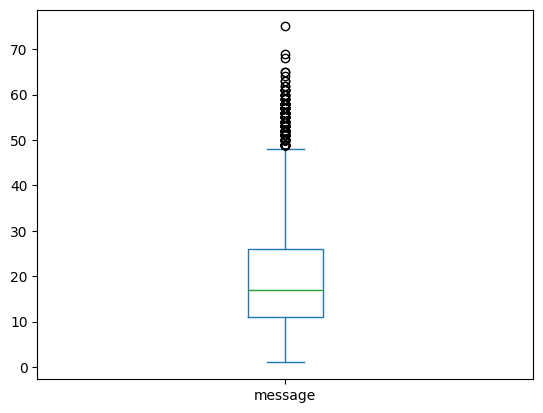

In [6]:
df["message"].str.split().apply(len).plot.box()

In [7]:
df = df[df["message"].str.split().apply(len) < 45].copy(deep=True)
df

,message,emotion
0,i used to be able to hang around talk with the...,anger
1,i get made to feel left out and unimportant in...,sadness
3,i feel extremely delicate and a bit helpless,love
4,i feel frightened that i might fail to notice ...,fear
5,i feel stubborn because i just want my seattle...,anger
...,...,...
11995,i feel useless for wasting k hours k just for ...,sadness
11996,i feel rushed and pulled and rung out and i kn...,anger
11997,i feel absolutely disgusted,anger
11998,i know that we are all sinners and fall short ...,sadness


<Axes: ylabel='Frequency'>

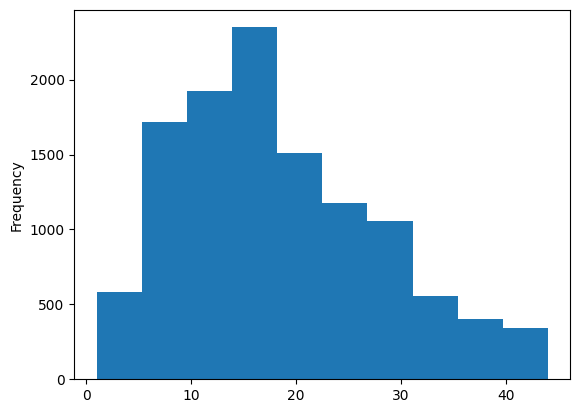

In [8]:
df["message"].str.split().apply(len).plot.hist()

<Axes: >

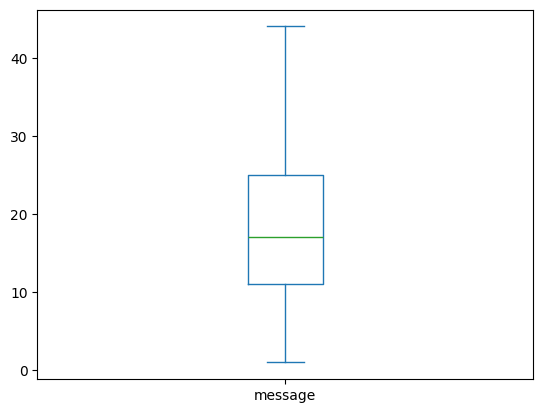

In [9]:
df["message"].str.split().apply(len).plot.box()

In [10]:
def get_vocabulary(texts: list[str]) -> list[str]:
    vocabulary = []
    for text in texts:
        for word in text.split(" "):
            vocabulary.append(word)
    return list(set(vocabulary))

In [11]:
vocabulary = get_vocabulary(df["message"].tolist())

In [12]:
len(vocabulary)

12665

In [13]:
max_vocabulary_size = 10000

In [14]:
X, y = df["message"], pd.get_dummies(df["emotion"]) 
# We use one-hot encoding for y so the neural network treats each emotion as a separate, 
# equal class instead of giving them numeric order.
# With 6 target classes, the neural network will have 6 output nodes, 
# each representing one class, and softmax will choose the most likely class among them.

In [15]:
y.head()

,anger,fear,joy,love,sadness,surprise
0,True,False,False,False,False,False
1,False,False,False,False,True,False
3,False,False,False,True,False,False
4,False,True,False,False,False,False
5,True,False,False,False,False,False


In [16]:
num_classes = y.shape[1]
num_classes

6

In [17]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

In [18]:
tokenizer = Tokenizer(num_words=max_vocabulary_size)  
# creates a tokenizer that will build a vocabulary of words,
# but will only keep the most frequent ones up to the specified maximum size;
# any rare or unknown words will be mapped to a special OOV (out-of-vocabulary) token
tokenizer.fit_on_texts(train_X.values)
# goes through every sentence in the training set and counts how often each word appears,
# building a dictionary that maps each word to a unique integer based on its frequency
train_X = tokenizer.texts_to_sequences(train_X)
# replaces each word in the training sentences with its corresponding integer ID from the learned vocabulary,
# turning text sentences into sequences of numbers that a neural network can process
test_X = tokenizer.texts_to_sequences(test_X)
# applies the same word-to-number mapping on the test sentences,
# ensuring the test data uses the exact same vocabulary learned from the training data

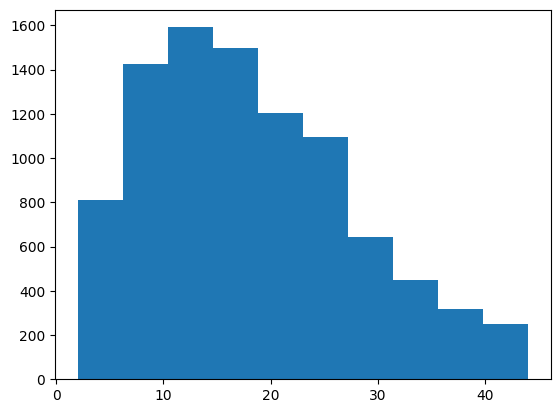

In [19]:
plt.hist([len(tokens) for tokens in train_X]);

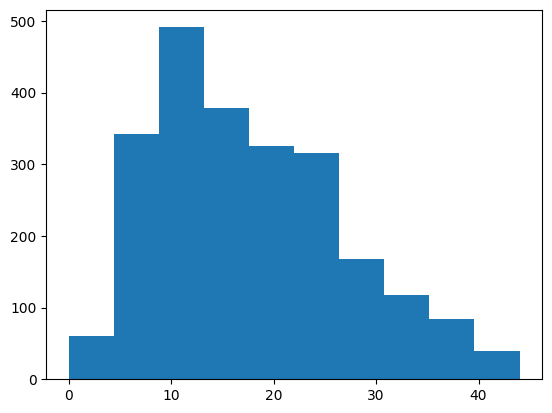

In [20]:
plt.hist([len(tokens) for tokens in test_X]);

In [21]:
maxlen = 32

In [22]:
# pad_sequences fixes all inputs to length = maxlen:
#   - sequences longer than maxlen are truncated
#   - shorter ones are padded (default with zeros)
# Models require equal-length inputs, so padding standardizes them.
train_X = sequence.pad_sequences(train_X, maxlen=maxlen)
test_X = sequence.pad_sequences(test_X, maxlen=maxlen)

In [23]:
train_X.shape, test_X.shape

((9285, 32), (2322, 32))

In [ ]:
model = Sequential([
    Embedding(input_dim=max_vocabulary_size, output_dim=128),
    # Converts word IDs into 128-dimensional vectors  
    # Produces dense numerical representations of words 
    Conv1D(filters=32, kernel_size=4, padding="same", activation="relu"),
    # Detects short patterns using 4-word windows and 32 pattern detectors
    # padding="same" keeps the output size equal to input size by padding the edges
    MaxPooling1D(pool_size=2),
    # Reduces sequence length by half and keeps the most prominent features  
    Conv1D(filters=64, kernel_size=4, padding="same", activation="relu"),
    MaxPooling1D(pool_size=2),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=True),
    # Processes the sequence in order and keeps information over timeabs
    # dropout: randomly removes part of the input connections during training
    # recurrent_dropout: randomly removes part of the internal memory connectionsabs
    # return_sequences=True returns the entire sequence instead of a single final vector
    # since the next layer should process every time step again
    LSTM(64, dropout=0.1, recurrent_dropout=0.1),
    Dense(num_classes, activation="softmax")
    # Produces a probability distribution over all classes   
])

In [25]:
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["precision", "recall", "f1_score"]
)

In [26]:
history = model.fit(train_X, train_y, validation_split=0.2, batch_size=64, epochs=3)

Epoch 1/3
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - f1_score: 0.1497 - loss: 1.7589 - precision: 0.2020 - recall: 0.0029 - val_f1_score: 0.3321 - val_loss: 1.2263 - val_precision: 0.6541 - val_recall: 0.1212
Epoch 2/3
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - f1_score: 0.5110 - loss: 1.0415 - precision: 0.7098 - recall: 0.2977 - val_f1_score: 0.7083 - val_loss: 0.6557 - val_precision: 0.7719 - val_recall: 0.7216
Epoch 3/3
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - f1_score: 0.8057 - loss: 0.5277 - precision: 0.8350 - recall: 0.7906 - val_f1_score: 0.8302 - val_loss: 0.5552 - val_precision: 0.8412 - val_recall: 0.8271


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 32, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 32, 32)         │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 16, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 16, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8, 128)         │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,359,860 (16.63 MB)

 Trainable params: 1,453,286 (5.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,906,574 (11.09 MB)

<Axes: >

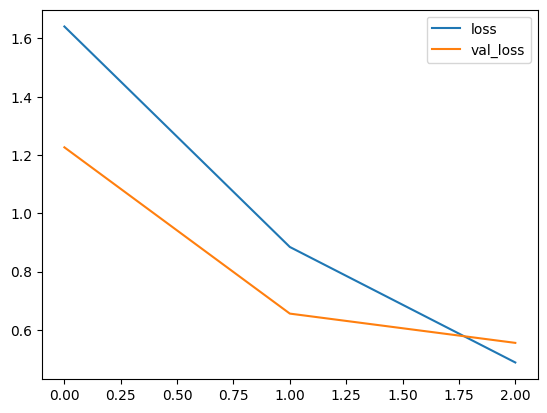

In [28]:
sns.lineplot(history.history["loss"], label="loss")
sns.lineplot(history.history["val_loss"], label="val_loss")

In [29]:
preds = model.predict(test_X)

73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [30]:
test_y = test_y.values.argmax(axis=1)
preds = preds.argmax(axis=1)

In [31]:
print(classification_report(test_y, preds))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       345
           1       0.81      0.72      0.76       383
           2       0.83      0.63      0.71       394
           3       0.87      0.95      0.91       417
           4       0.69      0.81      0.75       393
           5       0.87      0.97      0.92       390

    accuracy                           0.82      2322
   macro avg       0.83      0.82      0.82      2322
weighted avg       0.83      0.82      0.82      2322



Text(0.5, 1.0, 'Confusion Matrix')

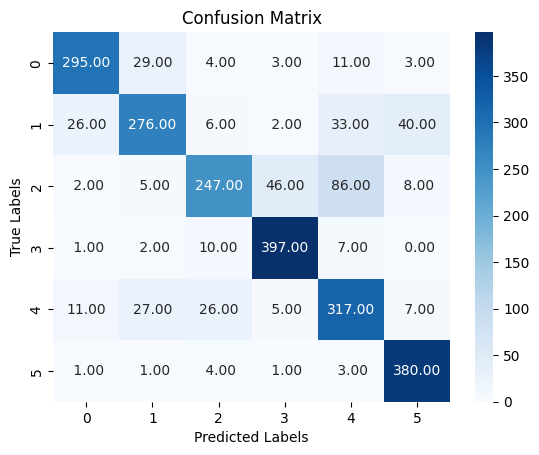

In [32]:
sns.heatmap(confusion_matrix(test_y, preds), annot=True, fmt="5.2f", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")

In [33]:
y.columns

Index(['anger', 'fear', 'joy', 'love', 'sadness', 'surprise'], dtype='object')